---------------- REVISAAAAR

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

from preprocessing import limpieza_base, construir_pipeline_ml

# 1. Cargar y Limpiar
df_raw = pd.read_csv('../dataset/bank-additional-full.csv', sep=';')
df_limpio = limpieza_base(df_raw)

# 2. Separar Features (X) y Target (y)
X = df_limpio.drop('y', axis=1)
y = df_limpio['y']

# 3. Dividir en Entrenamiento y Prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
# Nota: 'stratify=y' es vital aquí por el desbalanceo. Asegura que el 11% de "Sí" se reparta igual en train y test.

# 4. Entrenar y aplicar el Pipeline
pipeline = construir_pipeline_ml()

# Ajustamos (fit) y transformamos los datos de entrenamiento
X_train_procesado = pipeline.fit_transform(X_train)

# SOLO transformamos los datos de prueba (NUNCA hacer 'fit' en test)
X_test_procesado = pipeline.transform(X_test)

print("Forma de X_train original:", X_train.shape)
print("Forma de X_train procesado:", X_train_procesado.shape)

Forma de X_train original: (32686, 10)
Forma de X_train procesado: (32686, 29)


In [28]:
X_train

,age,job,contact,month,campaign,poutcome,emp.var.rate,cons.price.idx,euribor3m,nr.employed
899,46,technician,telephone,may,2,nonexistent,1.1,93.994,4.856,5191.0
25204,34,management,cellular,nov,2,nonexistent,-0.1,93.200,4.153,5195.8
21518,33,technician,cellular,aug,1,nonexistent,1.4,93.444,4.963,5228.1
36239,52,admin.,cellular,jun,1,nonexistent,-2.9,92.963,1.266,5076.2
21757,40,admin.,cellular,aug,2,nonexistent,1.4,93.444,4.963,5228.1
...,...,...,...,...,...,...,...,...,...,...
18270,41,management,telephone,jul,5,nonexistent,1.4,93.918,4.963,5228.1
9559,35,admin.,telephone,jun,1,nonexistent,1.4,94.465,4.961,5228.1
23657,45,management,cellular,aug,15,nonexistent,1.4,93.444,4.962,5228.1
9447,40,services,telephone,jun,3,nonexistent,1.4,94.465,4.967,5228.1


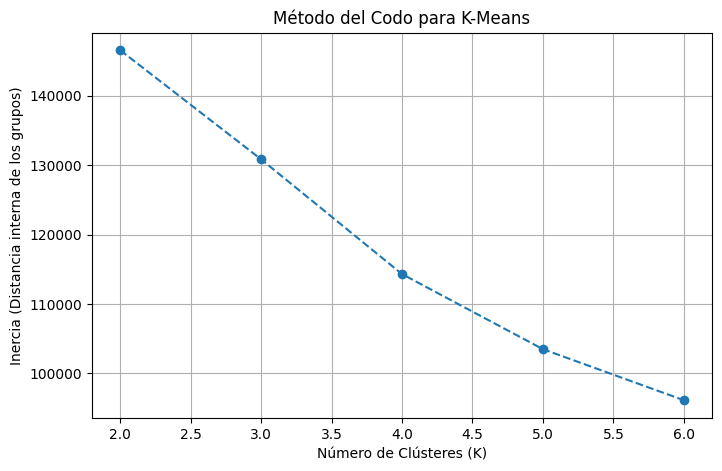

In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Vamos a probar dividiendo a los clientes desde 2 hasta 10 grupos
inercias = []
rango_k = range(2, 7)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_train_procesado) # Usamos los datos ya pasados por el pipeline
    inercias.append(kmeans_temp.inertia_)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Distancia interna de los grupos)')
plt.grid(True)
plt.show()

ENTRENAMIENTO modelo 1 (datos convinados, categoricos y numericos pero con encoded)

In [39]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1. Definir el K-Means Final (Cambiando n_clusters al número que te dio el codo)
n_clusters_ideal = 4
kmeans_final = KMeans(n_clusters=n_clusters_ideal, random_state=42, n_init=10)

# 2. Entrenar y predecir a qué grupo pertenece cada cliente
print("Entrenando K-Means final...")
clusters_asignados = kmeans_final.fit_predict(X_train_procesado)

# 3. Calcular Métricas para la comparativa con tu compañero
# IMPORTANTE: Calcular la silueta con 32,000 filas puede tardar unos minutos. ¡Paciencia!
print("\n--- MÉTRICAS DEL MODELO K-MEANS ---")

# Silhouette (Rango -1 a 1. Mientras más cerca de 1, mejor separados están los grupos)
silueta = silhouette_score(X_train_procesado, clusters_asignados)
print(f"1. Coeficiente de Silueta: {silueta:.4f} (Más alto es mejor)")

# Davies-Bouldin (Mide la dispersión. Mientras más cerca de 0, mejor)
davies = davies_bouldin_score(X_train_procesado, clusters_asignados)
print(f"2. Índice Davies-Bouldin: {davies:.4f} (Más bajo es mejor)")

# Calinski-Harabasz (Mide la densidad de los grupos. Más alto es mejor)
calinski = calinski_harabasz_score(X_train_procesado, clusters_asignados)
print(f"3. Índice Calinski-Harabasz: {calinski:.2f} (Más alto es mejor)")

Entrenando K-Means final...

--- MÉTRICAS DEL MODELO K-MEANS ---
1. Coeficiente de Silueta: 0.2626 (Más alto es mejor)
2. Índice Davies-Bouldin: 1.4676 (Más bajo es mejor)
3. Índice Calinski-Harabasz: 13315.04 (Más alto es mejor)


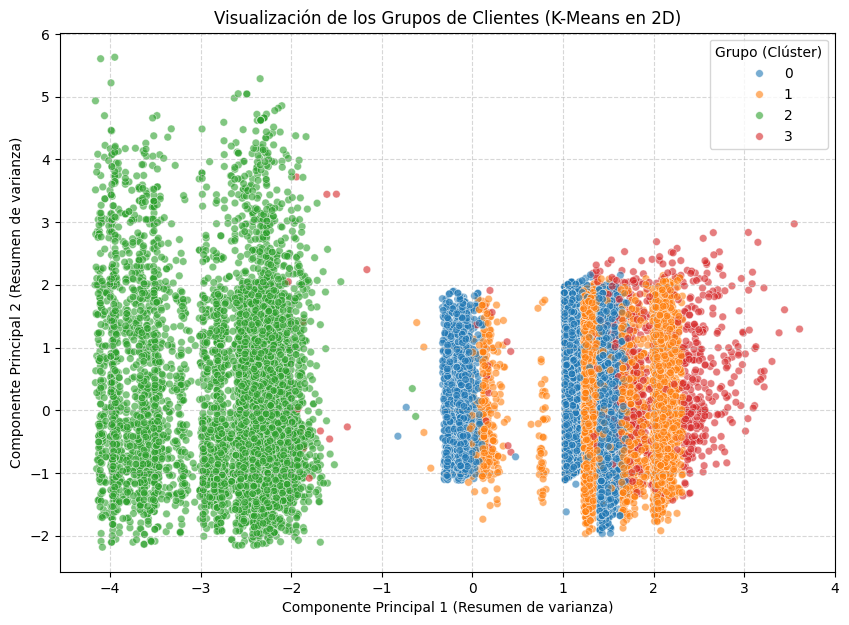

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Aplastar los datos a 2 dimensiones SOLO para el gráfico
pca_grafico = PCA(n_components=2)
X_grafico_2d = pca_grafico.fit_transform(X_train_procesado)

# 2. Crear el gráfico de dispersión
plt.figure(figsize=(10, 7))
# Usamos X_grafico_2d[:, 0] como eje X, X_grafico_2d[:, 1] como eje Y
# hue=clusters_asignados le da un color distinto a cada grupo de K-Means
sns.scatterplot(
    x=X_grafico_2d[:, 0], 
    y=X_grafico_2d[:, 1], 
    hue=clusters_asignados, 
    palette='tab10', # Paleta de colores bien diferenciada
    s=30,            # Tamaño de los puntos
    alpha=0.6        # Transparencia para ver dónde se acumulan más puntos
)

plt.title('Visualización de los Grupos de Clientes (K-Means en 2D)')
plt.xlabel('Componente Principal 1 (Resumen de varianza)')
plt.ylabel('Componente Principal 2 (Resumen de varianza)')
plt.legend(title='Grupo (Clúster)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Perfilamiento de grupso del modelo 1

In [ ]:
# 1. Copiamos tus datos originales limpios (antes de pasar por el pipeline)
df_perfiles = df_limpio.loc[X_train.index].copy()

# 2. Le pegamos la columna con los resultados de tu K-Means
# (Asegúrate de que df_limpio y clusters_asignados tengan el mismo largo)
df_perfiles['Cluster'] = clusters_asignados

# 3. Calculamos promedios para números y el valor más repetido (moda) para texto
resumen_perfiles = df_perfiles.groupby('Cluster').agg({
    'age': 'mean',                  # Promedio de edad
    'campaign': 'mean',             # Promedio de llamadas
    'job': lambda x: x.mode()[0],   # Profesión más común
    'month': lambda x: x.mode()[0], # Mes más común
    'y': 'mean'                     # % de éxito real en ese grupo
}).reset_index()

display(resumen_perfiles)

,Cluster,age,campaign,job,month,y
0,0,40.044629,2.248409,admin.,jul,0.057728
1,1,40.128503,2.285617,blue-collar,may,0.039742
2,2,39.624012,2.076816,admin.,may,0.243839
3,3,40.563745,14.059761,admin.,jul,0.035857


El modelo inicial de K-Means (K=4), entrenado con la totalidad del espectro de variables (tanto numéricas como categóricas codificadas mediante One-Hot Encoding), arrojó un Coeficiente de Silueta de 0.2626 y un índice Davies-Bouldin de 1.4676. Si bien estas métricas geométricas sugieren un solapamiento matemático en un espacio de alta dimensionalidad debido a la alta densidad de variables binarias (0 y 1), el perfilamiento resultante posee un alto valor estratégico para el negocio. El algoritmo identificó con éxito patrones de comportamiento críticos: un nicho de alta conversión (Clúster 2 con 24.3% de éxito) y un segmento de ineficiencia operativa (Clúster 3, caracterizado por una hiper-insistencia de 14 llamadas promedio y un éxito marginal del 3.5%). Se concluye que, aunque el modelo sufre de limitaciones matemáticas por el ruido de la codificación, es altamente interpretable a nivel comercial.

Modelo 2, solo usando variables numericas escaladas

In [64]:
from sklearn.preprocessing import StandardScaler
# 1. Tu idea: Creamos una variable nueva SOLO con las columnas numéricas originales
columnas_numericas = ['age', 'campaign', 'emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed']
X_train_solo_numeros = X_train[columnas_numericas].copy()

# 2. Escalamos los datos (K-Means siempre necesita datos escalados)
scaler = StandardScaler()
X_train_num_escalado = scaler.fit_transform(X_train_solo_numeros)

# 3. Entrenamos el K-Means con estos datos limpios
K_IDEAL_NUM = 4
kmeans_numerico = KMeans(n_clusters=K_IDEAL_NUM, random_state=42, n_init=10)
clusters_num_asignados = kmeans_numerico.fit_predict(X_train_num_escalado)

# 4. Calculamos las métricas
print("--- MÉTRICAS K-MEANS (SOLO VARIABLES NUMÉRICAS) ---")
silueta_num = silhouette_score(X_train_num_escalado, clusters_num_asignados)
davies_num = davies_bouldin_score(X_train_num_escalado, clusters_num_asignados)
calinski_num = calinski_harabasz_score(X_train_num_escalado, clusters_num_asignados)

print(f"1. Coeficiente de Silueta: {silueta_num:.4f} ")
print(f"2. Índice Davies-Bouldin: {davies_num:.4f} ")
print(f"3. Índice Calinski-Harabasz: {calinski_num:.2f} ")

--- MÉTRICAS K-MEANS (SOLO VARIABLES NUMÉRICAS) ---
1. Coeficiente de Silueta: 0.3651 
2. Índice Davies-Bouldin: 1.0042 
3. Índice Calinski-Harabasz: 22615.96 


Perfilamiento modelo 2

In [58]:
# 1. Copiamos las filas de entrenamiento de los datos originales limpios
df_perfiles_num = df_limpio.loc[X_train.index].copy()

# 2. Le pegamos los resultados del K-Means Numérico
df_perfiles_num['Cluster_Numerico'] = clusters_num_asignados

# 3. Agrupamos y calculamos estadísticas descriptivas para este nuevo modelo
resumen_perfiles_num = df_perfiles_num.groupby('Cluster_Numerico').agg({
    'age': 'mean',                  # Promedio de edad
    'campaign': 'mean',             # Promedio de llamadas
    'euribor3m': 'mean',            # Promedio de la tasa de interés (Económica)
    'emp.var.rate': 'mean',         # Promedio de variación de empleo (Económica)
    'job': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',   # Profesión predominante
    'month': lambda x: x.mode()[0] if not x.mode().empty else 'N/A', # Mes predominante
    'y': 'mean'                     # Tasa de éxito real (% de compras)
}).reset_index()

# 4. Contamos cuántos clientes cayeron en cada nuevo clúster
conteo_num = df_perfiles_num['Cluster_Numerico'].value_counts().reset_index()
conteo_num.columns = ['Cluster_Numerico', 'Cantidad_Clientes']
resumen_perfiles_num = resumen_perfiles_num.merge(conteo_num, on='Cluster_Numerico')

print("--- PERFILAMIENTO DE NEGOCIO (MODELO SÓLO NUMÉRICO) ---")
display(resumen_perfiles_num)

--- PERFILAMIENTO DE NEGOCIO (MODELO SÓLO NUMÉRICO) ---


,Cluster_Numerico,age,campaign,euribor3m,emp.var.rate,job,month,y,Cantidad_Clientes
0,0,40.053279,12.997541,4.869151,1.270984,admin.,jul,0.035246,1220
1,1,39.619907,2.073953,1.169028,-2.034465,admin.,may,0.243907,10750
2,2,33.637122,2.181398,4.813251,1.108458,admin.,may,0.051770,12343
3,3,49.658904,2.246387,4.806084,1.096453,blue-collar,may,0.045145,8373


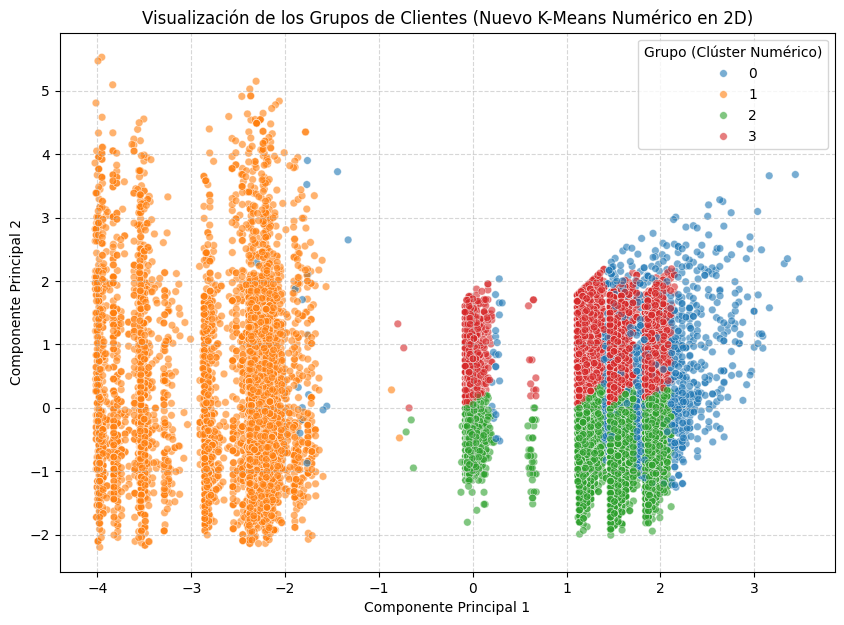

In [59]:
# 1. Aplastar los datos numéricos escalados a 2 dimensiones SOLO para el gráfico
pca_grafico_num = PCA(n_components=2)
X_grafico_2d_num = pca_grafico_num.fit_transform(X_train_num_escalado) # <--- Usamos el nuevo dataset numérico

# 2. Crear el gráfico de dispersión
plt.figure(figsize=(10, 7))
# Usamos X_grafico_2d_num[:, 0] como eje X, X_grafico_2d_num[:, 1] como eje Y
# hue=clusters_num_asignados le da un color distinto a cada grupo del nuevo K-Means
sns.scatterplot(
    x=X_grafico_2d_num[:, 0], 
    y=X_grafico_2d_num[:, 1], 
    hue=clusters_num_asignados, # <--- Usamos las nuevas etiquetas numéricas
    palette='tab10', # Paleta de colores bien diferenciada
    s=30,            # Tamaño de los puntos
    alpha=0.6        # Transparencia para ver dónde se acumulan más puntos
)

plt.title('Visualización de los Grupos de Clientes (Nuevo K-Means Numérico en 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupo (Clúster Numérico)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()